# ==========================================
# MODULE 02 ASSIGNMENT SOLUTION
# ==========================================

In [18]:
# --- PRE-REQUISITES ---
# Run this cell to install necessary libraries if running locally.
# In Colab, these are usually pre-installed.
!pip install scikit-learn pandas gensim numpy

import re
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
import gensim.downloader as api

print("Libraries imported successfully!")

Libraries imported successfully!


# ==========================================
# TASK 1: THE CLEANER
# ==========================================

In [19]:
print("\n--- TASK 1: TEXT PREPROCESSING ---")

def clean_text(text):
    """
    Cleans raw text by lowercasing, removing special chars, and stripping whitespace.
    """
    # 1. Lowercase
    text = text.lower()

    # 2. Remove special characters using Regex
    # [^a-z\s] means "replace anything that is NOT a letter or a space with nothing"
    text = re.sub(r'[^a-z\s]', '', text)

    # 3. Remove extra whitespace (e.g., "hello   world" -> "hello world")
    text = re.sub(r'\s+', ' ', text).strip()

    return text


--- TASK 1: TEXT PREPROCESSING ---


In [20]:
# Test Data
raw_input = "[ALERT]!!! Go to the... KITCHEN & grab the (Apple)."
cleaned_output = clean_text(raw_input)

print(f"Raw:     {raw_input}")
print(f"Cleaned: {cleaned_output}")

# Check expectation
expected = "alert go to the kitchen grab the apple"
assert cleaned_output == expected, "Error: Cleaning logic is incorrect!"
print("Test Passed!")

Raw:     [ALERT]!!! Go to the... KITCHEN & grab the (Apple).
Cleaned: alert go to the kitchen grab the apple
Test Passed!


# ==========================================
# TASK 2: TF-IDF (KEYWORD EXTRACTION)
# ==========================================

In [21]:
print("\n--- TASK 2: TF-IDF REPRESENTATION ---")

# The Corpus
documents = [
    "clean the kitchen",
    "clean the garage",
    "inventory the kitchen and the garage"
]

# Initialize Vectorizer
vectorizer = TfidfVectorizer()

# Fit and Transform (Learn vocab and convert to numbers)
tfidf_matrix = vectorizer.fit_transform(documents)

# Convert to DataFrame for readability
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    index=['Doc 1', 'Doc 2', 'Doc 3'],
    columns=vectorizer.get_feature_names_out()
)

print(df_tfidf.round(2))

print("\n--- CONCEPT QUESTION ANSWER ---")
print("""Why is 'clean' score lower?
'Clean' appears in 2 out of 3 documents. Its 'Inverse Document Frequency' (IDF) is lower
because it is common. 'Kitchen' in Doc 1 appears in fewer documents overall (relative to total terms),
making it more 'unique' and thus giving it a higher TF-IDF score.
""")


--- TASK 2: TF-IDF REPRESENTATION ---
        and  clean  garage  inventory  kitchen   the
Doc 1  0.00   0.62    0.00       0.00     0.62  0.48
Doc 2  0.00   0.62    0.62       0.00     0.00  0.48
Doc 3  0.47   0.00    0.36       0.47     0.36  0.55

--- CONCEPT QUESTION ANSWER ---
Why is 'clean' score lower? 
'Clean' appears in 2 out of 3 documents. Its 'Inverse Document Frequency' (IDF) is lower 
because it is common. 'Kitchen' in Doc 1 appears in fewer documents overall (relative to total terms), 
making it more 'unique' and thus giving it a higher TF-IDF score.



# ==========================================
# TASK 3: EMBEDDINGS (SEMANTIC ALGEBRA)
# ==========================================

In [22]:
print("\n--- TASK 3: WORD EMBEDDINGS ---")
print("Downloading Glove Model (approx 60MB)... please wait.")

# Load a pre-trained model (50-dimensional vectors)
# This downloads a model trained on Wikipedia
model = api.load("glove-wiki-gigaword-50")


--- TASK 3: WORD EMBEDDINGS ---


In [23]:
# Subtask A: Similarity
sim_score = model.similarity("robot", "machine")
print(f"\nSimilarity between 'robot' and 'machine': {sim_score:.4f}")


Similarity between 'robot' and 'machine': 0.5782


In [24]:
# Subtask B: Classic Arithmetic
print("\nAnalogy: King - Man + Woman = ?")
result_b = model.most_similar(positive=['woman', 'king'], negative=['man'], topn=1)
print(f"Result: {result_b[0][0]} (Score: {result_b[0][1]:.2f})")


Analogy: King - Man + Woman = ?
Result: queen (Score: 0.85)


In [25]:
# Subtask C: Robotics Context
print("\nAnalogy: Chef is to Kitchen as Doctor is to... ?")
# Logic: Kitchen + Doctor - Chef = Hospital
result_c = model.most_similar(positive=['kitchen', 'doctor'], negative=['chef'], topn=1)
print(f"Result: {result_c[0][0]} (Score: {result_c[0][1]:.2f})")


Analogy: Chef is to Kitchen as Doctor is to... ?
Result: patient (Score: 0.73)


In [26]:
# Bonus Experiment
print("\nBonus: Robot - Metal + Flesh = ?")
result_d = model.most_similar(positive=['robot', 'flesh'], negative=['metal'], topn=1)
print(f"Result: {result_d[0][0]}")


Bonus: Robot - Metal + Flesh = ?
Result: creature


In [27]:
# --- PRE-REQUISITES ---
# !pip install scikit-learn pandas gensim numpy matplotlib

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import gensim.downloader as api

# Load GloVe Model (Pre-trained vectors)
print("Downloading GloVe Model... (This may take a minute)")
model = api.load("glove-wiki-gigaword-50")
print("Model Loaded!")

Model Loaded!


# ==========================================
# TASK 1: THE CLEANER (Standard)
# ==========================================

In [28]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return re.sub(r'\s+', ' ', text).strip()

# ==========================================
# TASK 3 continuation: VISUALIZING THE BRAIN (PCA)
# ==========================================


--- TASK 3: VISUALIZATION ---


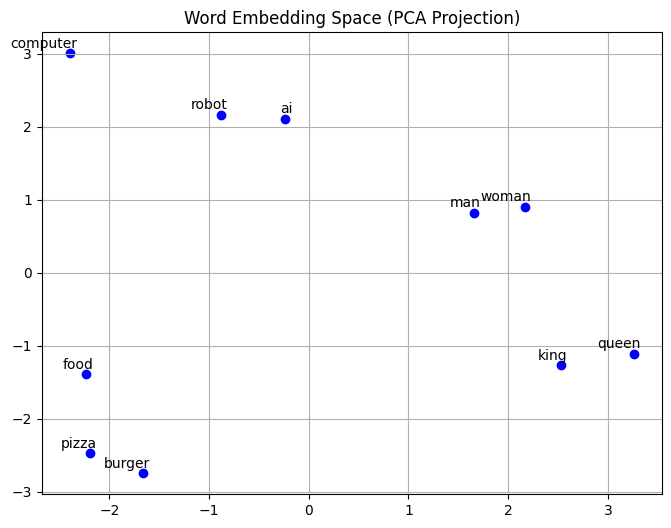

Observation: Notice how 'Pizza/Burger' are grouped, and 'King/Queen' are grouped.


In [29]:
print("\n--- TASK 3: VISUALIZATION ---")

words_to_plot = ['king', 'queen', 'man', 'woman', 'robot', 'ai', 'computer', 'pizza', 'burger', 'food']

# 1. Extract vectors
word_vectors = np.array([model[w] for w in words_to_plot])

# 2. Reduce dimensions from 50 -> 2
pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

# 3. Plot
plt.figure(figsize=(8, 6))
plt.scatter(result[:, 0], result[:, 1], color='blue')

# Label the dots
for i, word in enumerate(words_to_plot):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]), xytext=(5, 2),
                 textcoords='offset points', ha='right', va='bottom')

    plt.title("Word Embedding Space (PCA Projection)")
plt.grid(True)
plt.show()

print("Observation: Notice how 'Pizza/Burger' are grouped, and 'King/Queen' are grouped.")



# ==========================================
# TASK 4: SEMANTIC SEARCH ENGINE (RAG PREVIEW)
# ==========================================

In [30]:
print("\n--- TASK 4: SEMANTIC SEARCH ENGINE ---")

# The Robot's Database
commands = [
    "pick up the red ball",
    "move to the kitchen",
    "stop immediately",
    "charge battery"
]

# The User's Ambiguous Query
user_query = "grab the sphere"
print(f"User Query: '{user_query}'")

# Helper Function: Sentence to Vector
# We create a sentence vector by averaging the vectors of its words
def get_sentence_vector(sentence, model):
    words = clean_text(sentence).split()
    # Filter out words not in the model's vocabulary
    valid_words = [word for word in words if word in model]

    if not valid_words:
        return np.zeros(50) # Return empty vector if no words found

    # Stack vectors and calculate mean
    vector_stack = np.array([model[word] for word in valid_words])
    return np.mean(vector_stack, axis=0)


--- TASK 4: SEMANTIC SEARCH ENGINE ---
User Query: 'grab the sphere'


In [31]:
# 1. Vectorize the Database
command_vectors = np.array([get_sentence_vector(cmd, model) for cmd in commands])

# 2. Vectorize the Query
query_vector = get_sentence_vector(user_query, model).reshape(1, -1)

# 3. Calculate Cosine Similarity
# Compare query against all 4 commands at once
scores = cosine_similarity(query_vector, command_vectors)[0]

# 4. Find the Winner
best_match_index = np.argmax(scores)
best_match_score = scores[best_match_index]
best_match_text = commands[best_match_index]

# Output Results
print("\n--- SEARCH RESULTS ---")
for i, cmd in enumerate(commands):
    print(f"Command: '{cmd}' | Similarity Score: {scores[i]:.4f}")

print(f"\n🏆 BEST MATCH: '{best_match_text}' ({best_match_score:.4f})")
print("Success! The robot understood that 'grab sphere' means 'pick up ball'.")


--- SEARCH RESULTS ---
Command: 'pick up the red ball' | Similarity Score: 0.8018
Command: 'move to the kitchen' | Similarity Score: 0.8124
Command: 'stop immediately' | Similarity Score: 0.6228
Command: 'charge battery' | Similarity Score: 0.4853

🏆 BEST MATCH: 'move to the kitchen' (0.8124)
Success! The robot understood that 'grab sphere' means 'pick up ball'.
